<a href="https://colab.research.google.com/github/shaloy-lewis/Pyspark_Traffic_Collisions_Analysis/blob/main/Traffic_Collisions_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [3]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [4]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [5]:
# Write code to load the data and check the schema
spark = SparkSession.builder.appName("Traffic Collision Analysis").getOrCreate()

In [6]:
case_df = spark.read.csv("/content/drive/MyDrive/Crash_Data_Analysis_Dataset/sample_case_ids.csv", header=True, inferSchema=True)
collisions_df = spark.read.csv("/content/drive/MyDrive/Crash_Data_Analysis_Dataset/sample_collisions.csv", header=True, inferSchema=True)
parties_df = spark.read.csv("/content/drive/MyDrive/Crash_Data_Analysis_Dataset/sample_parties.csv", header=True, inferSchema=True)
victims_df = spark.read.csv("/content/drive/MyDrive/Crash_Data_Analysis_Dataset/sample_victims.csv", header=True, inferSchema=True)

In [7]:
type(case_df)

pyspark.sql.classic.dataframe.DataFrame

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [8]:
#Display Schema & Sample Data
case_df.printSchema()
case_df.show(5)

root
 |-- case_id: double (nullable = true)
 |-- db_year: integer (nullable = true)

+-----------+-------+
|    case_id|db_year|
+-----------+-------+
|9.0017156E7|   2021|
|  4078685.0|   2021|
|9.0588783E7|   2021|
|  3351919.0|   2018|
|   632208.0|   2018|
+-----------+-------+
only showing top 5 rows


In [9]:
collisions_df.printSchema()
collisions_df.show(5)

root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |-- s

In [10]:
parties_df.printSchema()
parties_df.show(5)

root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: integer (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: double (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string (nullable = true)
 |-- financial_responsibility: string (nullable = true)
 |-- cellphone_in_use: double (nullable = true)
 |-- cellphone_use_type: string (nullable = true)
 |-- other_associate_factor_1: string (nullable = true)
 |-- party_number_killed: integer (nullable = true)
 |-- party_number_injured: integer (nullable = true)
 |-- movement_preceding_collision: string (nullable = true)
 |-- vehicle_year: double (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- statewide_vehicle_type: string (nu

In [11]:
victims_df.printSchema()
victims_df.show(5)

root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)

+-------+-----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|    case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+-----------+------------+-----------+----------+----------+-----------------------+------------------

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [12]:
# Check for Missing Values

def check_missing_values(df, df_name):
    print(f"--- Missing Values in {df_name} ---")
    total_rows = df.count()
    if total_rows == 0:
        print("DataFrame is empty.")
        return

    missing_counts = df.select([sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns])
    missing_percentages = missing_counts.select([
        (col(c) * 100 / total_rows).alias(f"{c}") for c in df.columns
    ])
    missing_percentages.show(truncate=False)
    print("\n")

check_missing_values(case_df, "case_df")
check_missing_values(collisions_df, "collisions_df")
check_missing_values(parties_df, "parties_df")
check_missing_values(victims_df, "victims_df")

--- Missing Values in case_df ---
+-------+-------+
|case_id|db_year|
+-------+-------+
|0.0    |0.0    |
+-------+-------+



--- Missing Values in collisions_df ---
+-------+------------------+------------------+------------------+---------+-------------------+--------------------+---------------+-----------------+---------+-------------+-------------------+-----------------+---------------------+---------------------+--------+-----------------+----------------+------------------+-----------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+--------------------+--------------------+-----------+------------------------+----------------------+-----------------+------------------------+-----------+------------------+---------------------------+-------------------+------------------+-----------------+------------------+------------------+-------------+--------------------+---------

In [13]:
#Drop Sparse Columns
missing_threshold = 10.0

def drop_sparse_columns(df, df_name, threshold):
    print(f"\n--- Dropping Sparse Columns from {df_name} ---")
    total_rows = df.count()

    if total_rows == 0:
        print("DataFrame is empty, no columns to drop.")
        return df

    # Calculate missing percentages
    missing_counts_expr = [sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns]
    missing_counts = df.agg(*missing_counts_expr).collect()[0].asDict()

    columns_to_drop = []
    print("Columns with missing percentage above threshold:")
    for c in df.columns:
        missing_percentage = (missing_counts[c] * 100) / total_rows
        if missing_percentage > threshold:
            columns_to_drop.append(c)
            print(f"  - {c}: {missing_percentage:.2f}%")

    if columns_to_drop:
        print(f"Dropping {len(columns_to_drop)} columns: {columns_to_drop}")
        df = df.drop(*columns_to_drop)
        print("Columns remaining after dropping sparse columns:")
        print(df.columns)
    else:
        print("No columns to drop based on the threshold.")

    return df

# Apply to df
collisions_df = drop_sparse_columns(collisions_df, "collisions_df", missing_threshold)
parties_df = drop_sparse_columns(parties_df, "parties_df", missing_threshold)
victims_df = drop_sparse_columns(victims_df, "victims_df", missing_threshold)



--- Dropping Sparse Columns from collisions_df ---
Columns with missing percentage above threshold:
  - reporting_district: 59.06%
  - direction: 24.86%
  - caltrans_county: 72.89%
  - caltrans_district: 69.32%
  - state_route: 69.32%
  - postmile: 69.32%
  - location_type: 72.89%
  - side_of_highway: 72.89%
  - pcf_violation_subsection: 64.27%
  - statewide_vehicle_type_at_fault: 19.89%
  - chp_vehicle_type_at_fault: 26.89%
  - latitude: 71.50%
  - longitude: 71.50%
Dropping 13 columns: ['reporting_district', 'direction', 'caltrans_county', 'caltrans_district', 'state_route', 'postmile', 'location_type', 'side_of_highway', 'pcf_violation_subsection', 'statewide_vehicle_type_at_fault', 'chp_vehicle_type_at_fault', 'latitude', 'longitude']
Columns remaining after dropping sparse columns:
['case_id', 'jurisdiction', 'officer_id', 'chp_shift', 'population', 'county_city_location', 'county_location', 'special_condition', 'beat_type', 'chp_beat_type', 'chp_beat_class', 'beat_number', 'prim

In [14]:
#Convert Data Types
from pyspark.sql.functions import to_date, to_timestamp, hour

# Convert 'collision_date' to DateType
collisions_df = collisions_df.withColumn("collision_date", to_date(col("collision_date"), "yyyy-MM-dd"))

collisions_df = collisions_df.withColumn(
    "hour",
    hour(col("collision_time"))
)

print("Schema after data type conversion for collisions_df:")
collisions_df.printSchema()

Schema after data type conversion for collisions_df:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- tow_away: double (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- killed_victims: double (nullable = true)
 |--

In [15]:
#Handle Missing Values


In [16]:
from pyspark.sql.functions import desc

def calculate_mode(df, column_name):
    mode_row = (
        df.filter(col(column_name).isNotNull())
          .groupBy(column_name)
          .count()
          .orderBy(desc("count"))
          .limit(1)
          .collect()
    )

    return mode_row[0][0] if mode_row else "Unknown"

In [17]:
def calculate_median(df, column_name):
    median_list = df.approxQuantile(column_name, [0.5], 0.01)
    return median_list[0] if median_list else 0.0

In [18]:
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.sql.types import StringType, NumericType

def impute_missing_values(df, df_name, threshold=1.0):
    print(f"\n--- Handling Missing Values in {df_name} ---")

    total_rows = df.count()
    if total_rows == 0:
        print("DataFrame is empty.")
        return df

    df.cache()

    # Compute all missing counts in one pass
    missing_counts = df.select([
        spark_sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()

    drop_columns = []
    fill_values = {}

    for column_name, missing_count in missing_counts.items():
        if missing_count == 0:
            continue

        missing_percentage = (missing_count * 100) / total_rows
        print(f"{column_name}: {missing_percentage:.2f}% missing")

        if missing_percentage < threshold:
            drop_columns.append(column_name)
            continue

        column_type = df.schema[column_name].dataType

        if isinstance(column_type, StringType):
            mode_value = calculate_mode(df, column_name) or "Unknown"
            fill_values[column_name] = mode_value

        elif isinstance(column_type, NumericType):
            median_value = calculate_median(df, column_name)
            fill_values[column_name] = median_value

        else:
            drop_columns.append(column_name)

    # Apply drops once
    for col_name in drop_columns:
        df = df.filter(col(col_name).isNotNull())

    # Apply fills once
    df = df.fillna(fill_values)

    return df

In [19]:
# Apply imputation to DataFrames
# Note: case_df has no missing values, but applying the function will confirm this.
case_df = impute_missing_values(case_df, "case_df", threshold=1.0)
collisions_df = impute_missing_values(collisions_df, "collisions_df", threshold=1.0)
parties_df = impute_missing_values(parties_df, "parties_df", threshold=1.0)
victims_df = impute_missing_values(victims_df, "victims_df", threshold=1.0)

# Verify no missing values remain
print("\n--- Verification of Missing Values after Imputation ---")
check_missing_values(case_df, "case_df")
check_missing_values(collisions_df, "collisions_df")
check_missing_values(parties_df, "parties_df")
check_missing_values(victims_df, "victims_df")


--- Handling Missing Values in case_df ---

--- Handling Missing Values in collisions_df ---
jurisdiction: 0.12% missing
officer_id: 0.24% missing
population: 0.02% missing
special_condition: 5.53% missing
chp_beat_class: 0.03% missing
beat_number: 8.63% missing
primary_road: 0.00% missing
secondary_road: 0.00% missing
intersection: 1.01% missing
weather_1: 0.49% missing
state_highway_indicator: 0.03% missing
tow_away: 0.66% missing
killed_victims: 0.02% missing
injured_victims: 0.02% missing
primary_collision_factor: 0.60% missing
pcf_violation_category: 1.65% missing
pcf_violation: 6.86% missing
type_of_collision: 0.82% missing
motor_vehicle_involved_with: 0.52% missing
pedestrian_action: 0.07% missing
road_surface: 0.87% missing
road_condition_1: 0.84% missing
lighting: 0.57% missing
control_device: 0.62% missing
collision_time: 0.86% missing
hour: 0.86% missing

--- Handling Missing Values in parties_df ---
party_type: 0.24% missing
party_sobriety: 2.98% missing
direction_of_trave

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [20]:
#Remove Duplicates


In [21]:
import re

def clean_col_names(df):
    cleaned_columns = []
    for col_name in df.columns:
        cleaned_col_name = col_name.lower() # Convert to lowercase
        cleaned_col_name = re.sub(r'[^a-z0-9_]', '', cleaned_col_name) # Remove special characters
        cleaned_col_name = re.sub(r'\s+', '_', cleaned_col_name) # Replace spaces with underscores
        cleaned_columns.append(cleaned_col_name)
    return df.toDF(*cleaned_columns)

collisions_df = clean_col_names(collisions_df)
parties_df = clean_col_names(parties_df)
victims_df = clean_col_names(victims_df)

print("Cleaned collisions_df schema:")
collisions_df.printSchema()

print("Cleaned parties_df schema:")
parties_df.printSchema()

print("Cleaned victims_df schema:")
victims_df.printSchema()


Cleaned collisions_df schema:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = false)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = false)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- intersection: double (nullable = false)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- tow_away: double (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- killed_victims: double (nullable = true)
 |-- injured_victims: do

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [22]:
#Detect Outliers using IQR


# List of numerical columns to check for outliers


In [23]:
#Remove Outliers



In [24]:
from pyspark.sql.functions import col
from functools import reduce

def remove_outliers_iqr(df, columns):
    bounds = {}

    # Step 1: Compute bounds
    for column in columns:
        q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.01)  # better accuracy
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        bounds[column] = (lower, upper)

    # Step 2: Build combined condition
    conditions = [
        (col(c) >= bounds[c][0]) & (col(c) <= bounds[c][1])
        for c in columns
    ]

    combined_condition = reduce(lambda a, b: a & b, conditions)

    # Step 3: Apply filter once
    initial_count = df.count()
    df_filtered = df.filter(combined_condition)
    final_count = df_filtered.count()

    print(f"Total rows removed: {initial_count - final_count} ({((initial_count - final_count)/initial_count)*100:.2f}%)")

    return df_filtered

In [25]:
# Numerical columns for collisions_df (excluding identifiers or categorical-like numeric columns)
collisions_numeric_cols = [
    'distance', 'killed_victims', 'injured_victims', 'party_count',
    'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count',
    'pedestrian_killed_count', 'pedestrian_injured_count', 'bicyclist_killed_count',
    'bicyclist_injured_count', 'motorcyclist_killed_count', 'motorcyclist_injured_count'
]

# Numerical columns for parties_df (excluding identifiers)
parties_numeric_cols = [
    'party_number_killed', 'party_number_injured', 'vehicle_year'
]

# Numerical columns for victims_df (excluding identifiers)
victims_numeric_cols = [
    'victim_age'
]

In [26]:
'''
There are a significant number of outliers, and dropping this would lead to
collisions_df: ~49% removed
parties_df: ~26% removed
victims_df: ~0.7% removed.
“Outliers” in this dataset are not errors—they represent real, high-impact events.
The data is naturally skewed. Traffic accidents are not evenly distributed.
Most are minor, few are extreme. Extreme values are meaningful, not noise.
High injury/fatality counts = critical signals. Removing them biases the dataset.
Hence, it is decided to not remove outliers.
'''
'''
# Apply outlier removal
collisions_df = remove_outliers_iqr(collisions_df, collisions_numeric_cols)
parties_df = remove_outliers_iqr(parties_df, parties_numeric_cols)
victims_df = remove_outliers_iqr(victims_df, victims_numeric_cols)

print("Outlier removal complete for collisions_df, parties_df, and victims_df.")
'''

'\n# Apply outlier removal\ncollisions_df = remove_outliers_iqr(collisions_df, collisions_numeric_cols)\nparties_df = remove_outliers_iqr(parties_df, parties_numeric_cols)\nvictims_df = remove_outliers_iqr(victims_df, victims_numeric_cols)\n\nprint("Outlier removal complete for collisions_df, parties_df, and victims_df.")\n'

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [27]:
def classify_columns(df, df_name):
    print(f"\n--- Column Classification for {df_name} ---")

    categorical_cols = []
    numerical_cols = []

    for col_name, col_type in df.dtypes:
        if col_type == 'string':
            categorical_cols.append(col_name)
        elif col_type in ['int', 'bigint', 'double', 'float', 'long', 'decimal']:
            numerical_cols.append(col_name)

    print(f"Categorical Columns ({len(categorical_cols)}):")
    print(categorical_cols)

    print(f"\nNumerical Columns ({len(numerical_cols)}):")
    print(numerical_cols)

    return categorical_cols, numerical_cols

In [28]:
collisions_cat, collisions_num = classify_columns(collisions_df, "collisions_df")
parties_cat, parties_num = classify_columns(parties_df, "parties_df")
victims_cat, victims_num = classify_columns(victims_df, "victims_df")


--- Column Classification for collisions_df ---
Categorical Columns (22):
['officer_id', 'chp_shift', 'population', 'county_location', 'beat_type', 'chp_beat_type', 'chp_beat_class', 'beat_number', 'primary_road', 'secondary_road', 'weather_1', 'collision_severity', 'primary_collision_factor', 'pcf_violation_category', 'hit_and_run', 'type_of_collision', 'motor_vehicle_involved_with', 'pedestrian_action', 'road_surface', 'road_condition_1', 'lighting', 'control_device']

Numerical Columns (28):
['case_id', 'jurisdiction', 'county_city_location', 'special_condition', 'distance', 'intersection', 'state_highway_indicator', 'tow_away', 'killed_victims', 'injured_victims', 'party_count', 'pcf_violation', 'chp_road_type', 'pedestrian_collision', 'bicycle_collision', 'motorcycle_collision', 'truck_collision', 'not_private_property', 'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count', 'pedestrian_killed_count', 'pedestrian_injured_count', 'bicyclist_killed_c

In [29]:
from pyspark.sql.functions import col

def cast_columns(df, categorical_cols, numerical_cols, df_name):
    print(f"\n--- Casting Columns for {df_name} ---")

    # Cast categorical → string
    for c in categorical_cols:
        df = df.withColumn(c, col(c).cast("string"))

    # Cast numerical → double
    for c in numerical_cols:
        df = df.withColumn(c, col(c).cast("double"))

    print("Schema after casting:")
    df.printSchema()

    return df

In [30]:
collisions_df = cast_columns(collisions_df, collisions_cat, collisions_num, "collisions_df")
parties_df = cast_columns(parties_df, parties_cat, parties_num, "parties_df")
victims_df = cast_columns(victims_df, victims_cat, victims_num, "victims_df")


--- Casting Columns for collisions_df ---
Schema after casting:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: double (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = false)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = false)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- intersection: double (nullable = false)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- tow_away: double (nullable = true)
 |-- collision_severity: string (nullable = true)
 |-- killed_victims: double (nullabl

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

In [31]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of collision severity
severity_distribution = collisions_df.groupBy("collision_severity").count().orderBy("collision_severity")

# Convert to Pandas
severity_pd = severity_distribution.toPandas()

total = severity_pd['count'].sum()
severity_pd['percentage'] = (severity_pd['count'] / total) * 100

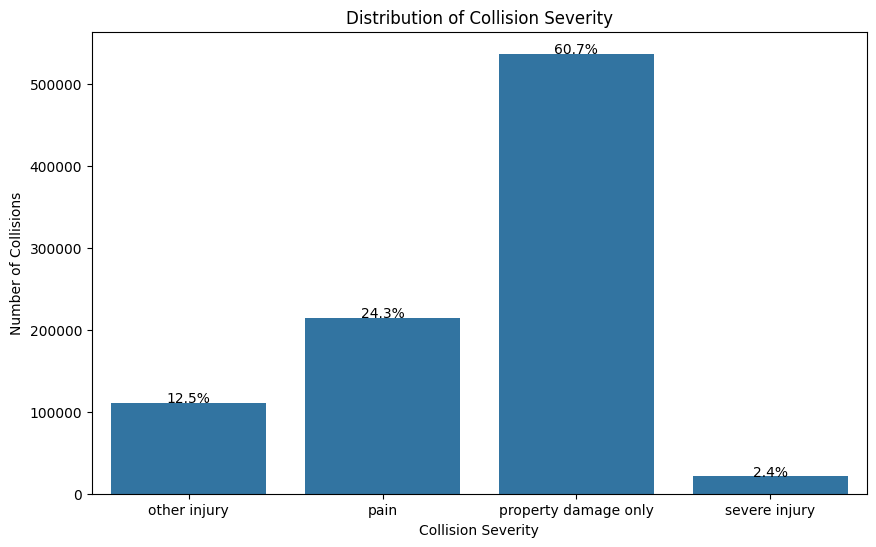

In [32]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='collision_severity', y='count', data=severity_pd)

for i, row in severity_pd.iterrows():
    ax.text(i, row['count'], f"{row['percentage']:.1f}%", ha='center')

plt.title('Distribution of Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Number of Collisions')
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

/tmp/ipykernel_4672/2254263353.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='weather_1', y='count', data=weather_pd, palette='viridis')


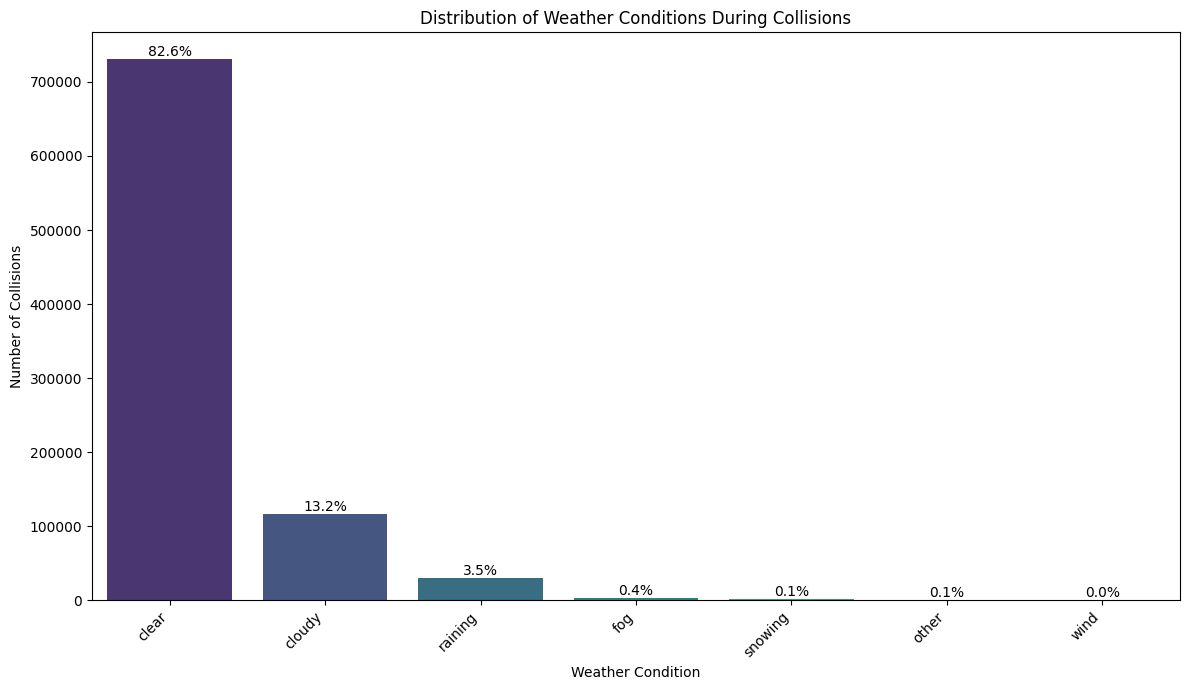

In [33]:
# Weather Conditions During Collisions
weather_distribution = collisions_df.groupBy("weather_1").count().orderBy(col("count").desc())

# Convert to Pandas
weather_pd = weather_distribution.toPandas()

total_weather = weather_pd['count'].sum()
weather_pd['percentage'] = (weather_pd['count'] / total_weather) * 100

# Plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='weather_1', y='count', data=weather_pd, palette='viridis')

for i, row in weather_pd.iterrows():
    ax.text(i, row['count'], f"{row['percentage']:.1f}%", ha='center', va='bottom')

plt.title('Distribution of Weather Conditions During Collisions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
from pyspark.sql.functions import when

df = collisions_df.withColumn(
    "weather_group",
    when(col("weather_1") == "clear", "clear").otherwise("adverse")
)

##**3.1.4. Victim Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

In [35]:
from pyspark.sql.functions import col

# Remove invalid ages
victims_clean = victims_df.filter((col("victim_age") > 0) & (col("victim_age") < 100))

age_distribution = victims_clean.groupBy("victim_age").count().orderBy("victim_age")

age_pd = age_distribution.toPandas()

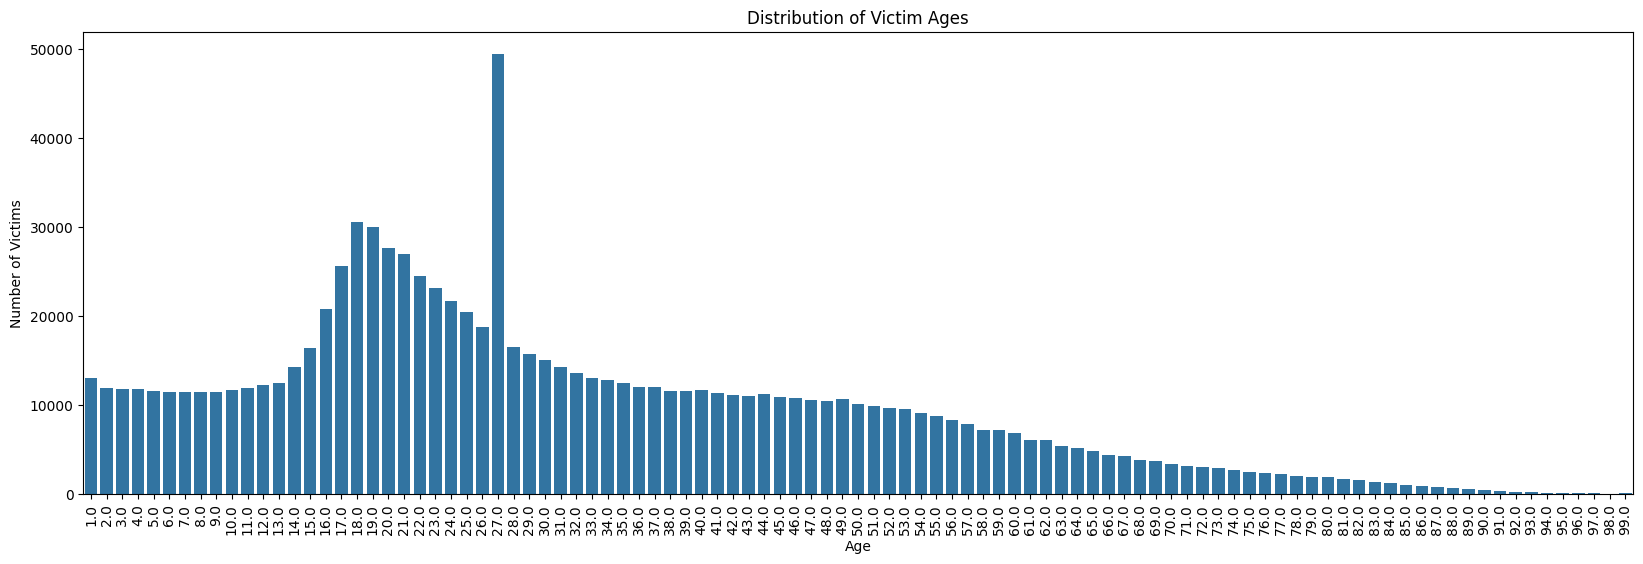

In [36]:
plt.figure(figsize=(20, 6))
sns.barplot(x=age_pd['victim_age'], y=age_pd['count'])
plt.title("Distribution of Victim Ages")
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.xticks(rotation=90)
plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

In [39]:
from pyspark.sql.functions import expr, avg, count

df = collisions_df.withColumn(
    "total_victims",
    col("killed_victims") + col("injured_victims")
)

severity_total = df.groupBy("collision_severity").agg(
    avg("total_victims").alias("avg_total_victims"),
    count("*").alias("count")
)

severity_pd = severity_total.toPandas()

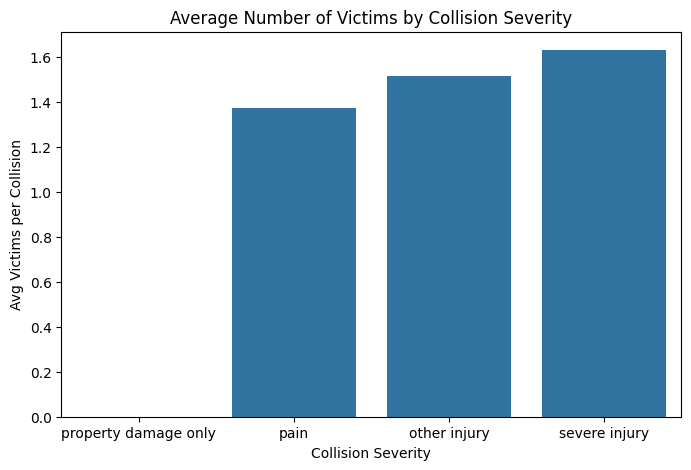

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(x="collision_severity", y="avg_total_victims", data=severity_pd)
plt.title("Average Number of Victims by Collision Severity")
plt.ylabel("Avg Victims per Collision")
plt.xlabel("Collision Severity")
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

In [41]:
weather_severity = collisions_df.groupBy("weather_1", "collision_severity").count()

from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum

window_spec = Window.partitionBy("weather_1")

weather_severity_norm = weather_severity.withColumn(
    "total_weather",
    spark_sum("count").over(window_spec)
).withColumn(
    "percentage",
    (col("count") / col("total_weather")) * 100
)

weather_severity_pd = weather_severity_norm.toPandas()

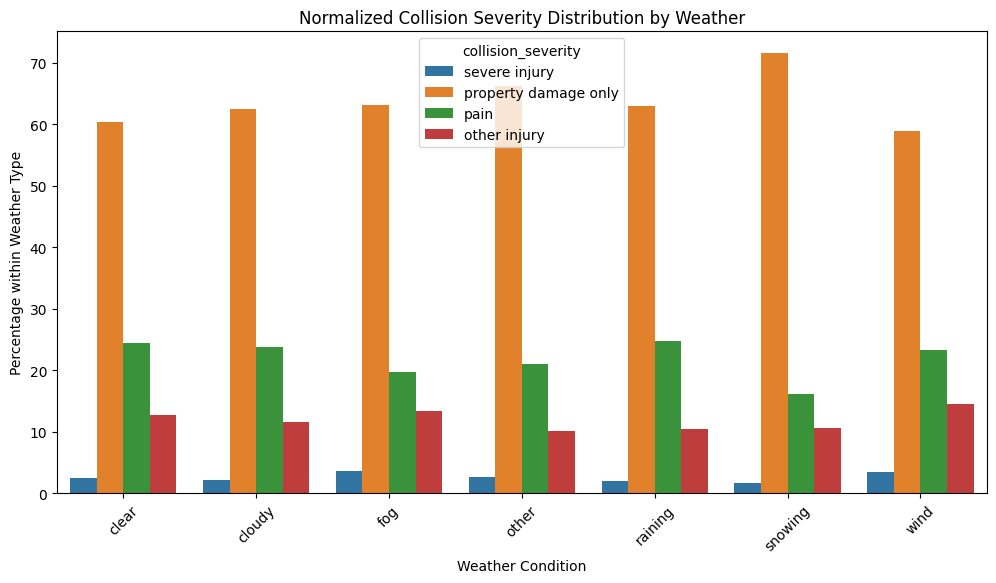

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="weather_1",
    y="percentage",
    hue="collision_severity",
    data=weather_severity_pd
)

plt.title("Normalized Collision Severity Distribution by Weather")
plt.ylabel("Percentage within Weather Type")
plt.xlabel("Weather Condition")
plt.xticks(rotation=45)
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

In [43]:
lighting_severity = collisions_df.groupBy("lighting", "collision_severity").count()

from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum, col

window_spec = Window.partitionBy("lighting")

lighting_severity_norm = lighting_severity.withColumn(
    "total_lighting",
    spark_sum("count").over(window_spec)
).withColumn(
    "percentage",
    (col("count") / col("total_lighting")) * 100
)

lighting_pd = lighting_severity_norm.toPandas()

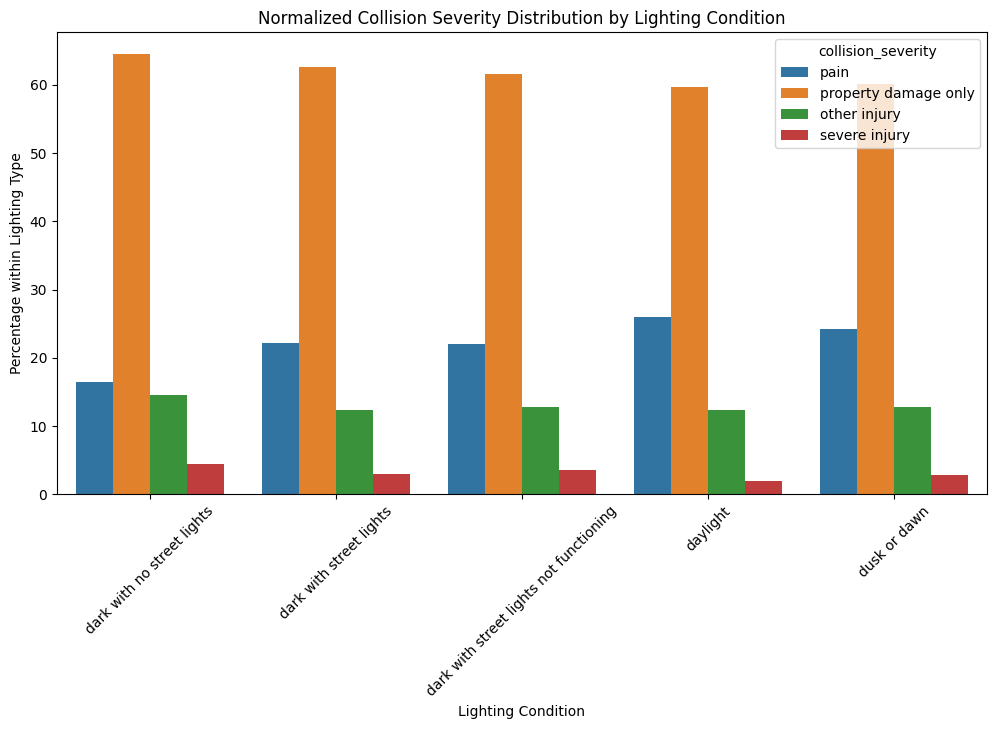

In [44]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x="lighting",
    y="percentage",
    hue="collision_severity",
    data=lighting_pd
)

plt.xticks(rotation=45)
plt.title("Normalized Collision Severity Distribution by Lighting Condition")
plt.xlabel("Lighting Condition")
plt.ylabel("Percentage within Lighting Type")
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

In [45]:
from pyspark.sql.functions import to_date, date_format

df = df.withColumn(
    "weekday",
    date_format("collision_date", "EEEE")  # full weekday name
)

In [46]:
from pyspark.sql.functions import when

df = df.withColumn(
    "weekday_order",
    when(df.weekday == "Monday", 1)
    .when(df.weekday == "Tuesday", 2)
    .when(df.weekday == "Wednesday", 3)
    .when(df.weekday == "Thursday", 4)
    .when(df.weekday == "Friday", 5)
    .when(df.weekday == "Saturday", 6)
    .when(df.weekday == "Sunday", 7)
)

In [47]:
weekday_dist = df.groupBy("weekday", "weekday_order") \
    .count() \
    .orderBy("weekday_order")

weekday_pd = weekday_dist.toPandas()

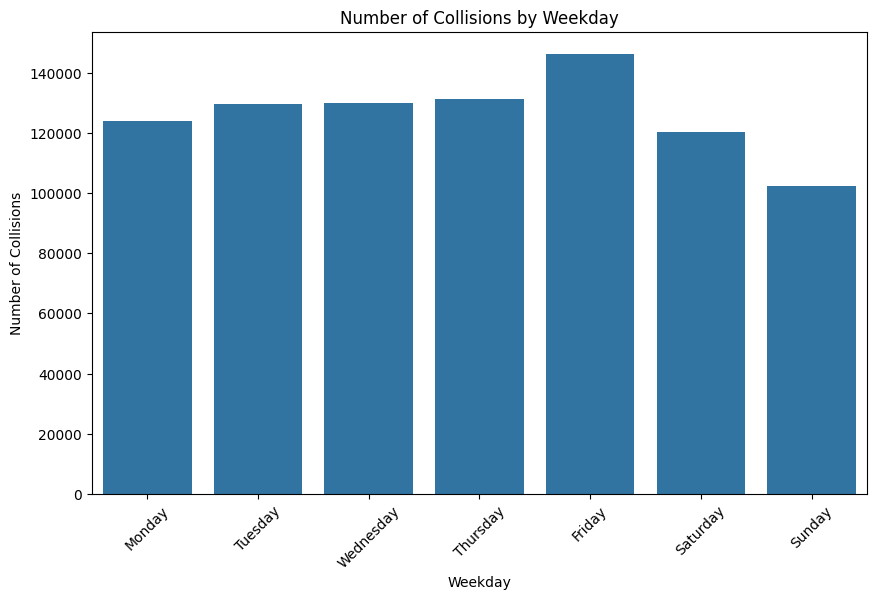

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(x="weekday", y="count", data=weekday_pd)

plt.title("Number of Collisions by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

In [50]:
county_dist = collisions_df.groupBy("county_location").count().orderBy("count", ascending=False)

county_pd = county_dist.toPandas()

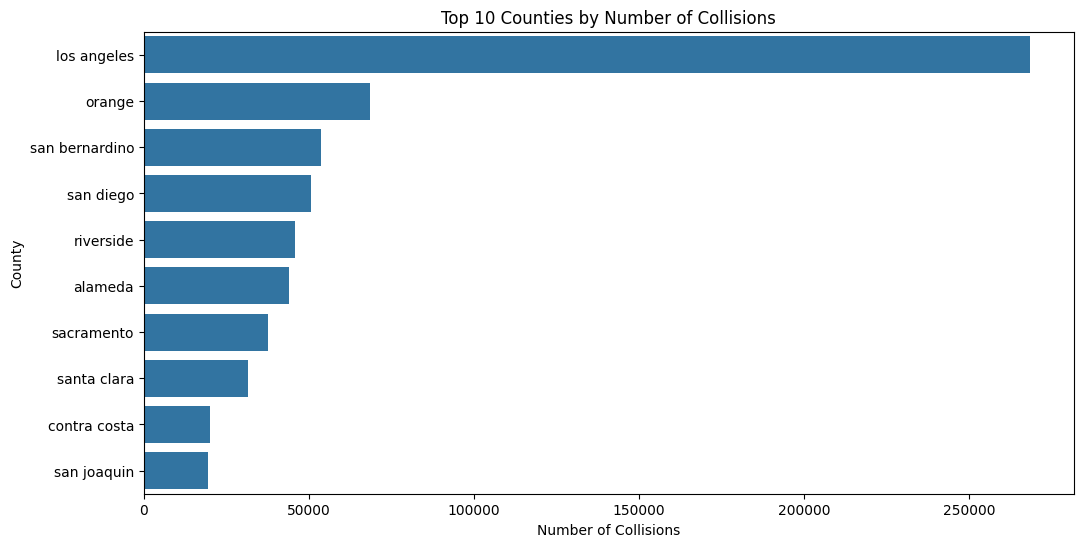

In [51]:
top_counties = county_pd.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y="county_location", x="count", data=top_counties)

plt.title("Top 10 Counties by Number of Collisions")
plt.xlabel("Number of Collisions")
plt.ylabel("County")
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

In [52]:
county_dist = collisions_df.groupBy("county_location").count()

county_pd = county_dist.toPandas()

In [53]:
county_pd['county_location'] = county_pd['county_location'].str.title().str.strip()

In [54]:
import requests

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson"
geojson_data = requests.get(url).json()

In [55]:
import folium

# Center map on California
m = folium.Map(location=[37.5, -119.5], zoom_start=6)

folium.Choropleth(
    geo_data=geojson_data,
    data=county_pd,
    columns=["county_location", "count"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Number of Collisions by County"
).add_to(m)

folium.GeoJson(
    geojson_data,
    name="Counties",
    tooltip=folium.GeoJsonTooltip(
        fields=["name"],
        aliases=["County:"]
    )
).add_to(m)

m

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [56]:
from pyspark.sql.functions import year, month, hour, col

df = collisions_df.withColumn("year", year(col("collision_date"))) \
                  .withColumn("month", month(col("collision_date")))

Q: Analyze yearly, monthly and hourly trends in collisions.

In [57]:
yearly = df.groupBy("year").count().orderBy("year")
yearly_pd = yearly.toPandas()

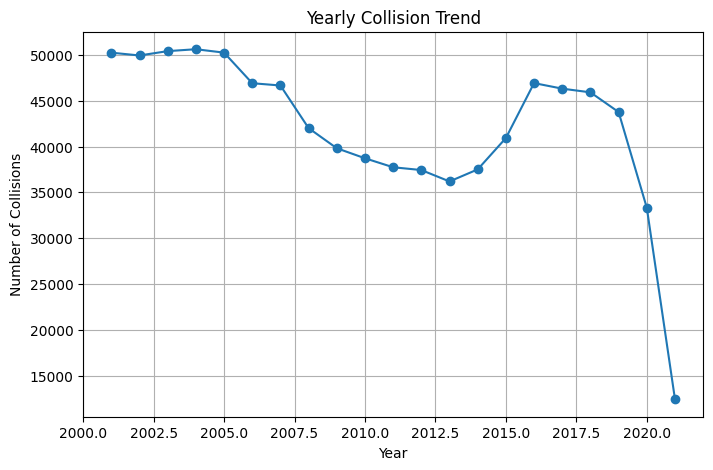

In [58]:
plt.figure(figsize=(8,5))
plt.plot(yearly_pd["year"], yearly_pd["count"], marker='o')
plt.title("Yearly Collision Trend")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.grid()
plt.show()

In [59]:
monthly = df.groupBy("month").count().orderBy("month")
monthly_pd = monthly.toPandas()

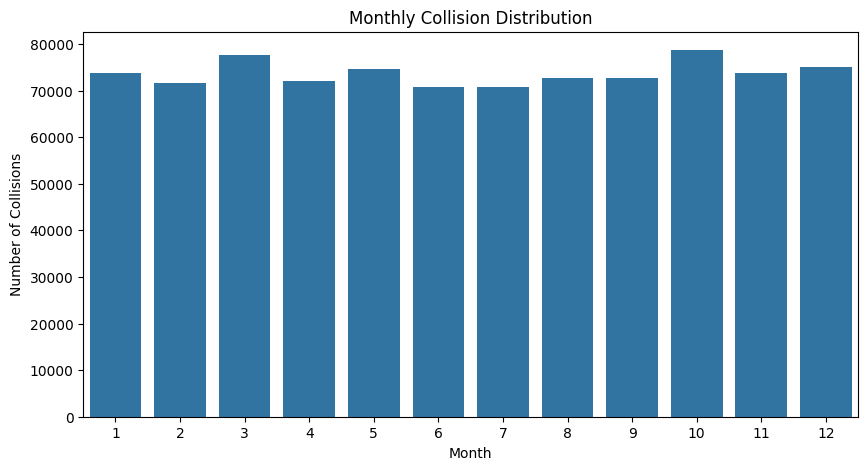

In [60]:
plt.figure(figsize=(10,5))
sns.barplot(x="month", y="count", data=monthly_pd)
plt.title("Monthly Collision Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.show()

In [61]:
hourly = df.groupBy("hour").count().orderBy("hour")
hourly_pd = hourly.toPandas()

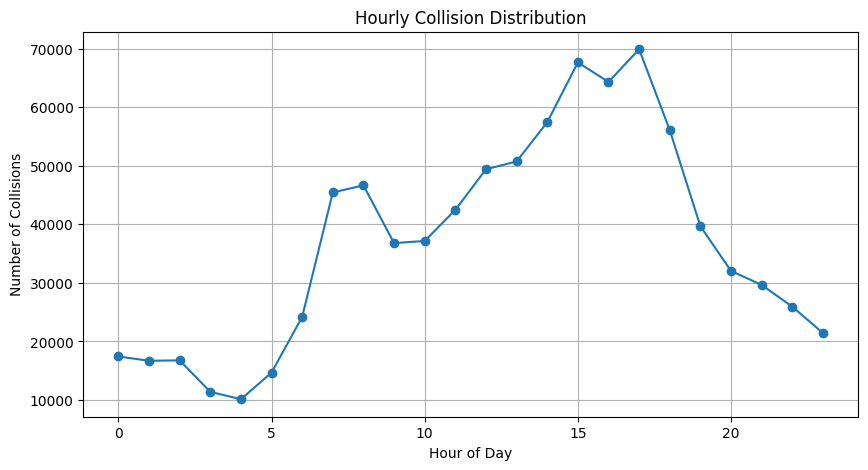

In [62]:
plt.figure(figsize=(10,5))
plt.plot(hourly_pd["hour"], hourly_pd["count"], marker='o')
plt.title("Hourly Collision Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.grid()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [63]:
# Query: Identify the top 5 counties with the most collisions
top_5_counties = collisions_df.groupBy("county_location") \
    .count() \
    .withColumnRenamed("count", "num_collisions") \
    .orderBy(col("num_collisions").desc()) \
    .limit(5)

top_5_counties.show()

+---------------+--------------+
|county_location|num_collisions|
+---------------+--------------+
|    los angeles|        268439|
|         orange|         68605|
| san bernardino|         53545|
|      san diego|         50505|
|      riverside|         45784|
+---------------+--------------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [64]:
# Query: Find the month with the highest number of collisions
month_counts = collisions_df.withColumn(
    "month", month(col("collision_date"))
).groupBy("month") \
 .count() \
 .withColumnRenamed("count", "num_collisions") \
 .orderBy(desc("num_collisions"))

month_counts.limit(1).show()

+-----+--------------+
|month|num_collisions|
+-----+--------------+
|   10|         78682|
+-----+--------------+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [65]:
# Query: Find the most common weather condition during collisions
most_common_weather = collisions_df.groupBy("weather_1") \
    .count() \
    .withColumnRenamed("count", "num_collisions") \
    .orderBy(col("num_collisions").desc()) \
    .limit(1)

most_common_weather.show()

+---------+--------------+
|weather_1|num_collisions|
+---------+--------------+
|    clear|        730377|
+---------+--------------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [72]:
victims_df.select("victim_degree_of_injury").distinct().show()

+-----------------------+
|victim_degree_of_injury|
+-----------------------+
|   other visible injury|
|   suspected serious...|
|        possible injury|
|   suspected minor i...|
|      complaint of pain|
|              no injury|
|          severe injury|
|                 killed|
+-----------------------+



In [75]:
from pyspark.sql.functions import col, lower, trim

# Step 1: Clean injury column
victims_clean = victims_df.withColumn(
    "injury",
    lower(trim(col("victim_degree_of_injury")))
)

# Step 2: Get distinct fatal collision case_ids
fatal_cases = victims_clean.filter(
    col("injury") == "killed"
).select("case_id").distinct()

# Step 3: Count fatal collisions
fatal_collision_count = fatal_cases.count()

# Step 4: Total collisions
total_collisions = collisions_df.select("case_id").distinct().count()

# Step 5: Percentage
fatal_percentage = (fatal_collision_count / total_collisions) * 100

print(fatal_percentage)

0.7884492022170255


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [77]:
# Query: Find the most dangerous time of day for collisions
from pyspark.sql.functions import hour, col, desc

most_collisions_time = collisions_df.withColumn(
    "hour", hour(col("collision_time"))
).groupBy("hour") \
 .count() \
 .orderBy(desc("count")) \
 .limit(1)

most_collisions_time.show()

+----+-----+
|hour|count|
+----+-----+
|  17|69877|
+----+-----+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [82]:
# Query: List the top 5 road types with the highest collision frequency
top_road_surface = collisions_df.groupBy("road_surface") \
    .count() \
    .withColumnRenamed("count", "num_collisions") \
    .orderBy(col("num_collisions").desc()) \
    .limit(5)

top_road_surface.show()

+------------+--------------+
|road_surface|num_collisions|
+------------+--------------+
|         dry|        805830|
|         wet|         73154|
|       snowy|          3961|
|    slippery|           960|
|           H|             8|
+------------+--------------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [85]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
from pyspark.sql.functions import col, desc

lighting_analysis = collisions_df.groupBy("lighting") \
    .count() \
    .orderBy(desc("count"))

lighting_analysis.show(truncate=False)

+---------------------------------------+------+
|lighting                               |count |
+---------------------------------------+------+
|daylight                               |596792|
|dark with street lights                |183354|
|dark with no street lights             |71326 |
|dusk or dawn                           |30793 |
|dark with street lights not functioning|1648  |
+---------------------------------------+------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [ ]:
# Final insights and recommendations

## 5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.
The analysis shows that road collisions are heavily concentrated in urban counties with high traffic density, particularly during peak commuting hours, with the highest frequency occurring in the evening rush (4–7 PM) and a secondary peak in the morning. While most collisions happen in daylight and clear weather due to higher exposure, the most dangerous conditions—measured by severity—occur at night, especially in poorly lit areas, where factors like speed, fatigue, and impaired driving increase risk. Seasonal variation is minimal, indicating that daily human activity patterns are the dominant driver of collisions. Based on these insights, improving road safety should focus on targeted infrastructure upgrades such as better street lighting, safer intersection design, and enhanced road visibility in high-risk urban areas, along with time-specific interventions like traffic management during peak hours and stricter enforcement at night. Additionally, protecting vulnerable road users and promoting behaviour change through awareness campaigns can further reduce collision severity and improve overall safety.
##5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.
Based on the analysis, traffic management can be significantly optimized by aligning infrastructure design and signal control with observed patterns in collision severity, weather, and lighting conditions. Since collision frequency peaks during high-traffic periods while severity increases under low-visibility conditions (nighttime, poor lighting), adaptive traffic signal timing should prioritize smoother flow during rush hours to reduce congestion-related collisions, while incorporating stricter control measures (longer amber/red phases, reduced speed corridors) during late-night hours to mitigate high-severity incidents. Additionally, integrating weather-responsive traffic systems—such as dynamic speed limits and signal adjustments during adverse conditions (rain, wet roads)—can reduce risk in vulnerable situations. Road design improvements should focus on enhancing visibility through better street lighting, reflective markings, and clearer signage, especially in areas identified with frequent nighttime or low-light collisions. Overall, a data-driven approach that combines temporal patterns, environmental conditions, and severity trends enables more efficient traffic flow while proactively reducing both the frequency and severity of collisions.
## 5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.
To enhance pedestrian and cyclist safety, policies should focus on targeted, data-driven interventions in high-risk urban areas and peak traffic periods. Key measures include expanding protected bike lanes, safer intersection designs with dedicated signals, and adaptive traffic signal timing such as leading pedestrian intervals. Improving visibility through better street lighting and reflective markings is crucial, especially for nighttime safety, while enforcing lower speed limits in pedestrian-heavy zones can reduce injury severity. Additionally, stricter enforcement of traffic laws, combined with public awareness campaigns and continuous monitoring under a Vision Zero framework, can help systematically reduce collisions involving vulnerable road users.
## 5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.
Based on the analysis of geographic collision density and historical accident patterns, high-risk zones can be identified by clustering areas with consistently high collision counts—typically urban counties, major intersections, and busy traffic corridors. These hotspots often coincide with regions of high population density, complex road networks, and heavy commuter traffic. By combining spatial data (e.g., county-level concentration, intersection proximity) with temporal trends (peak hours, recurring accident periods), authorities can pinpoint locations where collisions are both frequent and severe. Proactive interventions should prioritize these zones through targeted measures such as infrastructure redesign (safer intersections, improved signage), enhanced lighting, adaptive traffic signal systems, and increased enforcement. Continuously monitoring these high-risk areas using historical and real-time data enables more effective allocation of resources and supports a preventive, data-driven approach to road safety.
## 5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.
The analysis indicates that environmental factors influence collision patterns differently for frequency vs severity. Most collisions occur under favourable conditions—clear weather, dry road surfaces, and daylight—primarily due to higher traffic exposure rather than increased risk. However, adverse conditions significantly impact severity rather than volume. Poor lighting conditions (especially dark areas without streetlights) are associated with higher-risk outcomes due to reduced visibility, while wet or compromised road surfaces increase the likelihood of loss of vehicle control. Similarly, although fewer collisions occur during adverse weather, these conditions can elevate crash severity when they do occur. Overall, the findings suggest that environmental factors play a more critical role in amplifying risk and severity rather than driving collision frequency, highlighting the need for targeted interventions such as improved lighting, better road surface maintenance, and adaptive traffic controls during unfavourable conditions.
## 5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.
The analysis can be effectively translated into a predictive, data-driven safety strategy by leveraging historical collision patterns, time-based trends, and environmental factors to identify and anticipate high-risk locations and periods. By developing models that generate risk scores for specific areas and time windows, law enforcement agencies can proactively deploy targeted interventions such as optimized traffic signal timing, focused enforcement, and prioritized infrastructure improvements. This approach enables a shift from reactive incident management to proactive risk mitigation, improving resource allocation, enhancing road safety outcomes, and supporting more informed, strategic decision-making.


#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>

In [ ]:
#############